# 02 PlantVillage YOLOv8n Transfer Detection

**Final detection pipeline**

**Model:** YOLOv8n  
**Transfer path:** COCO-pretrained weights → PlantDoc real detection → PlantVillage mask-derived tight leaf boxes  
**Target task:** whole-leaf localization + PlantVillage disease-class prediction  
**Not lesion-level detection**

This notebook is designed to be:

- **Run-All friendly**
- **Auto-resumable after power/runtime disconnection**
- **Portable across Google accounts**
- **Independent of previous Colab runtimes**

## Before Run All

1. Select a **T4 GPU** runtime.
2. The mounted Google Drive must contain:

```text
MyDrive/PlantVillage_Detection/
├── final_detection_manifest_v2.csv
├── detection_class_map.json
└── detection_preprocessing_config_v2.json
```

3. To resume this same model from another Gmail account, copy the **entire**
`MyDrive/PlantVillage_Detection/` folder, including the model's `experiments/YOLOv8n/`
folder, to the other account at the same path.

The notebook recreates temporary datasets under `/content/` on every runtime.  
Persistent checkpoints/results are written to Google Drive.


# STEP 1 — Install Libraries

In [1]:
!pip -q install ultralytics kagglehub pyyaml


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.8 MB/s eta 0:00:00


# STEP 2 — Imports, GPU, and Reproducibility

In [2]:
import os
import gc
import json
import time
import random
import shutil
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import yaml
import torch

from tqdm.auto import tqdm
from ultralytics import YOLO
import ultralytics
import kagglehub

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU not available. Enable a T4 GPU before running this notebook."
    )

DEVICE = 0

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))
print("Seed:", SEED)


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics: 8.4.152
PyTorch: 2.11.0+cu128
GPU: Tesla T4
Seed: 42


# STEP 3 — Mount Google Drive and Define Persistent Paths

In [3]:
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/PlantVillage_Detection"
)

EXPERIMENT_DIR = (
    PROJECT_DIR /
    "experiments" /
    "YOLOv8n"
)

RESULTS_DIR = (
    EXPERIMENT_DIR /
    "results"
)

PLANTDOC_RUN_DIR = (
    EXPERIMENT_DIR /
    "01_plantdoc_pretrain"
)

PLANTVILLAGE_RUN_DIR = (
    EXPERIMENT_DIR /
    "02_plantvillage_finetune"
)

TEST_EVAL_DIR = (
    EXPERIMENT_DIR /
    "03_test_evaluation"
)

PREDICTION_DIR = (
    EXPERIMENT_DIR /
    "04_sample_predictions"
)

for folder in [
    PROJECT_DIR,
    EXPERIMENT_DIR,
    RESULTS_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

FINAL_MANIFEST = (
    PROJECT_DIR /
    "final_detection_manifest_v2.csv"
)

CLASS_MAP_PATH = (
    PROJECT_DIR /
    "detection_class_map.json"
)

PREPROCESSING_CONFIG_PATH = (
    PROJECT_DIR /
    "detection_preprocessing_config_v2.json"
)

print("Project:", PROJECT_DIR)
print("Experiment:", EXPERIMENT_DIR)


Mounted at /content/drive
Project: /content/drive/MyDrive/PlantVillage_Detection
Experiment: /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n


# STEP 4 — Verify Final Detection Preprocessing Artifacts

In [4]:
for path in [
    FINAL_MANIFEST,
    CLASS_MAP_PATH,
    PREPROCESSING_CONFIG_PATH
]:
    print(
        "✅" if path.exists() else "❌",
        path
    )
    assert path.exists()

manifest_df = pd.read_csv(
    FINAL_MANIFEST
)

with open(
    CLASS_MAP_PATH,
    "r"
) as f:
    class_map = json.load(f)

with open(
    PREPROCESSING_CONFIG_PATH,
    "r"
) as f:
    preprocessing_config = json.load(f)

print("\nFinal samples:", len(manifest_df))
print(manifest_df["split"].value_counts())
print("Classes:", manifest_df["class"].nunique())

assert len(manifest_df) == 52959
assert (manifest_df["split"] == "train").sum() == 42363
assert (manifest_df["split"] == "val").sum() == 5300
assert (manifest_df["split"] == "test").sum() == 5296
assert manifest_df["class"].nunique() == 38
assert manifest_df["sample_id"].duplicated().sum() == 0

id_to_class = class_map["id_to_class"]

CLASS_NAMES = [
    id_to_class[str(i)]
    for i in range(38)
]

for i, name in enumerate(CLASS_NAMES):
    assert (
        manifest_df.loc[
            manifest_df["class_id"] == i,
            "class"
        ].eq(name).all()
    )

print("\n✅ Final detection manifest verified.")


✅ /content/drive/MyDrive/PlantVillage_Detection/final_detection_manifest_v2.csv
✅ /content/drive/MyDrive/PlantVillage_Detection/detection_class_map.json
✅ /content/drive/MyDrive/PlantVillage_Detection/detection_preprocessing_config_v2.json

Final samples: 52959
split
train    42363
val       5300
test      5296
Name: count, dtype: int64
Classes: 38

✅ Final detection manifest verified.


# STEP 5 — Common Training Configuration

In [5]:
MODEL_LABEL = "YOLOv8n"
BASE_WEIGHTS = "yolov8n.pt"

IMG_SIZE = 320
BATCH_SIZE = 16
WORKERS = 2

PLANTDOC_EPOCHS = 15
PLANTDOC_PATIENCE = 5

PLANTVILLAGE_EPOCHS = 20
PLANTVILLAGE_PATIENCE = 7

OPTIMIZER = "AdamW"
LR0 = 1e-3
WEIGHT_DECAY = 5e-4

WORK_DIR = Path(
    "/content/plantvillage_detection_work"
)

PV_YOLO_DIR = (
    WORK_DIR /
    "plantvillage_yolo_tight_boxes"
)

PLANTDOC_FIXED_YAML = (
    WORK_DIR /
    "plantdoc_fixed.yaml"
)

PLANTVILLAGE_YAML = (
    WORK_DIR /
    "plantvillage_tight_boxes.yaml"
)

WORK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Model:", MODEL_LABEL)
print("Base weights:", BASE_WEIGHTS)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("PlantDoc epochs:", PLANTDOC_EPOCHS)
print("PlantVillage epochs:", PLANTVILLAGE_EPOCHS)


Model: YOLOv8n
Base weights: yolov8n.pt
Image size: 320
Batch size: 16
PlantDoc epochs: 15
PlantVillage epochs: 20


# STEP 6 — Download PlantVillage

In [6]:
plantvillage_download = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset"
)

plantvillage_base = Path(
    plantvillage_download
)

print(
    "PlantVillage download:",
    plantvillage_base
)


100%|██████████| 2.04G/2.04G [00:58<00:00, 37.3MB/s]

Extracting files...


PlantVillage download: /root/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3


# STEP 7 — Detect PlantVillage Dataset Root

In [7]:
def find_plantvillage_root(base):

    required = {
        "color",
        "grayscale",
        "segmented"
    }

    candidates = [base]

    candidates.extend(
        p
        for p in base.rglob("*")
        if p.is_dir()
    )

    for path in candidates:

        try:
            folder_names = {
                x.name
                for x in path.iterdir()
                if x.is_dir()
            }

            if required.issubset(
                folder_names
            ):
                return path

        except PermissionError:
            continue

    return None


PV_DATASET_ROOT = find_plantvillage_root(
    plantvillage_base
)

assert PV_DATASET_ROOT is not None
assert (PV_DATASET_ROOT / "color").exists()

print(
    "PlantVillage dataset root:",
    PV_DATASET_ROOT
)


PlantVillage dataset root: /root/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3/plantvillage dataset


# STEP 8 — Download PlantDoc Real Object-Detection Dataset

In [8]:
plantdoc_download = kagglehub.dataset_download(
    "yusufmurtaza01/plantdoc-object-detection-dataset"
)

plantdoc_base = Path(
    plantdoc_download
)

print(
    "PlantDoc download:",
    plantdoc_base
)


100%|██████████| 934M/934M [00:26<00:00, 37.2MB/s]

Extracting files...


PlantDoc download: /root/.cache/kagglehub/datasets/yusufmurtaza01/plantdoc-object-detection-dataset/versions/1


# STEP 9 — Prepare a Stable PlantDoc YAML

In [9]:
def count_images(folder):
    exts = {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    }

    return sum(
        1
        for p in Path(folder).rglob("*")
        if p.is_file()
        and p.suffix.lower() in exts
    )


def find_plantdoc_yaml(base):

    yaml_files = (
        list(base.rglob("dataset.yaml"))
        +
        list(base.rglob("data.yaml"))
    )

    for yaml_path in yaml_files:

        try:
            with open(
                yaml_path,
                "r"
            ) as f:
                data = yaml.safe_load(f)

            if not isinstance(
                data,
                dict
            ):
                continue

            if not all(
                key in data
                for key in [
                    "train",
                    "val",
                    "names"
                ]
            ):
                continue

            root = yaml_path.parent

            train_images = (
                root /
                "images" /
                "train"
            )

            val_images = (
                root /
                "images" /
                "val"
            )

            if not val_images.exists():
                val_images = (
                    root /
                    "images" /
                    "valid"
                )

            train_labels = (
                root /
                "labels" /
                "train"
            )

            val_labels = (
                root /
                "labels" /
                val_images.name
            )

            if (
                train_images.exists()
                and
                val_images.exists()
                and
                train_labels.exists()
                and
                val_labels.exists()
            ):
                return (
                    yaml_path,
                    data,
                    root,
                    train_images,
                    val_images
                )

        except Exception:
            continue

    raise FileNotFoundError(
        "Valid PlantDoc dataset.yaml was not found."
    )


(
    plantdoc_original_yaml_path,
    plantdoc_original_yaml,
    PLANTDOC_ROOT,
    plantdoc_train_images,
    plantdoc_val_images
) = find_plantdoc_yaml(
    plantdoc_base
)


plantdoc_names = (
    plantdoc_original_yaml[
        "names"
    ]
)

plantdoc_nc = len(
    plantdoc_names
)

plantdoc_train_count = count_images(
    plantdoc_train_images
)

plantdoc_val_count = count_images(
    plantdoc_val_images
)


assert plantdoc_nc == 29
assert plantdoc_train_count == 2335
assert plantdoc_val_count == 236


plantdoc_fixed_data = {
    "train":
        str(
            plantdoc_train_images
        ),

    "val":
        str(
            plantdoc_val_images
        ),

    "nc":
        plantdoc_nc,

    "names":
        plantdoc_names
}


with open(
    PLANTDOC_FIXED_YAML,
    "w"
) as f:

    yaml.safe_dump(
        plantdoc_fixed_data,
        f,
        sort_keys=False
    )


print(
    "PlantDoc train:",
    plantdoc_train_count
)

print(
    "PlantDoc val:",
    plantdoc_val_count
)

print(
    "PlantDoc classes:",
    plantdoc_nc
)

print(
    "Fixed YAML:",
    PLANTDOC_FIXED_YAML
)

print(
    "\n✅ PlantDoc is ready."
)


PlantDoc train: 2335
PlantDoc val: 236
PlantDoc classes: 29
Fixed YAML: /content/plantvillage_detection_work/plantdoc_fixed.yaml

✅ PlantDoc is ready.


# STEP 10 — Rebuild PlantVillage YOLO Dataset from the FINAL Manifest

In [10]:
if PV_YOLO_DIR.exists():
    shutil.rmtree(
        PV_YOLO_DIR
    )

for split in [
    "train",
    "val",
    "test"
]:
    (
        PV_YOLO_DIR /
        "images" /
        split
    ).mkdir(
        parents=True,
        exist_ok=True
    )

    (
        PV_YOLO_DIR /
        "labels" /
        split
    ).mkdir(
        parents=True,
        exist_ok=True
    )


def create_runtime_image_link(
    source,
    destination
):
    source = Path(source)
    destination = Path(
        destination
    )

    try:
        os.symlink(
            str(
                source.resolve()
            ),
            str(destination)
        )

    except OSError:
        shutil.copy2(
            source,
            destination
        )


print(
    "Building temporary YOLO dataset..."
)


for row in tqdm(
    manifest_df.itertuples(
        index=False
    ),
    total=len(manifest_df)
):

    source_image = (
        PV_DATASET_ROOT /
        row.color_rel
    )

    if not source_image.exists():
        raise FileNotFoundError(
            source_image
        )

    suffix = (
        source_image.suffix.lower()
        or
        ".jpg"
    )

    image_name = (
        str(row.sample_id)
        +
        suffix
    )

    output_image = (
        PV_YOLO_DIR /
        "images" /
        row.split /
        image_name
    )

    output_label = (
        PV_YOLO_DIR /
        "labels" /
        row.split /
        (
            str(row.sample_id)
            +
            ".txt"
        )
    )


    create_runtime_image_link(
        source_image,
        output_image
    )


    label_line = (
        f"{int(row.class_id)} "
        f"{float(row.x_center):.8f} "
        f"{float(row.y_center):.8f} "
        f"{float(row.box_width):.8f} "
        f"{float(row.box_height):.8f}\n"
    )


    output_label.write_text(
        label_line,
        encoding="utf-8"
    )


plantvillage_yaml_data = {
    "train":
        str(
            PV_YOLO_DIR /
            "images" /
            "train"
        ),

    "val":
        str(
            PV_YOLO_DIR /
            "images" /
            "val"
        ),

    "test":
        str(
            PV_YOLO_DIR /
            "images" /
            "test"
        ),

    "nc":
        38,

    "names":
        CLASS_NAMES
}


with open(
    PLANTVILLAGE_YAML,
    "w"
) as f:

    yaml.safe_dump(
        plantvillage_yaml_data,
        f,
        sort_keys=False
    )


print(
    "PlantVillage YAML:",
    PLANTVILLAGE_YAML
)

print(
    "✅ Runtime YOLO dataset built."
)


Building temporary YOLO dataset...


  0%|          | 0/52959 [00:00<?, ?it/s]

PlantVillage YAML: /content/plantvillage_detection_work/plantvillage_tight_boxes.yaml
✅ Runtime YOLO dataset built.


# STEP 11 — Verify Runtime YOLO Dataset

In [11]:
verification_rows = []

expected_counts = {
    "train": 42363,
    "val": 5300,
    "test": 5296
}


for split in [
    "train",
    "val",
    "test"
]:

    image_dir = (
        PV_YOLO_DIR /
        "images" /
        split
    )

    label_dir = (
        PV_YOLO_DIR /
        "labels" /
        split
    )

    image_count = sum(
        1
        for p in image_dir.iterdir()
        if p.is_file()
        or p.is_symlink()
    )

    label_count = len(
        list(
            label_dir.glob(
                "*.txt"
            )
        )
    )

    verification_rows.append({
        "split":
            split,

        "images":
            image_count,

        "labels":
            label_count,

        "expected":
            expected_counts[
                split
            ]
    })

    assert (
        image_count
        ==
        expected_counts[
            split
        ]
    )

    assert (
        label_count
        ==
        expected_counts[
            split
        ]
    )


verification_df = pd.DataFrame(
    verification_rows
)

display(
    verification_df
)


sample_label = next(
    (
        PV_YOLO_DIR /
        "labels" /
        "train"
    ).glob("*.txt")
)

print(
    "\nSample label:",
    sample_label
)

print(
    sample_label.read_text()
)

print(
    "✅ Image/label counts match."
)


,split,images,labels,expected
0,train,42363,42363,42363
1,val,5300,5300,5300
2,test,5296,5296,5296



Sample label: /content/plantvillage_detection_work/plantvillage_yolo_tight_boxes/labels/train/c90526ecde2c8897.txt
24 0.46289062 0.48437500 0.76171875 0.83593750

✅ Image/label counts match.


# STEP 12 — Save Experiment Configuration

In [12]:
EXPERIMENT_CONFIG = {
    "model":
        "YOLOv8n",

    "base_weights":
        "yolov8n.pt",

    "transfer_pipeline":
        "COCO pretrained -> PlantDoc -> PlantVillage",

    "plantdoc_dataset":
        "yusufmurtaza01/plantdoc-object-detection-dataset",

    "plantdoc_train_images":
        plantdoc_train_count,

    "plantdoc_validation_images":
        plantdoc_val_count,

    "plantdoc_classes":
        plantdoc_nc,

    "plantvillage_samples":
        len(manifest_df),

    "plantvillage_train":
        42363,

    "plantvillage_validation":
        5300,

    "plantvillage_test":
        5296,

    "plantvillage_classes":
        38,

    "annotation":
        "mask-derived tight whole-leaf bounding boxes",

    "lesion_level_detection":
        False,

    "image_size":
        IMG_SIZE,

    "batch_size":
        BATCH_SIZE,

    "plantdoc_epochs":
        PLANTDOC_EPOCHS,

    "plantvillage_epochs":
        PLANTVILLAGE_EPOCHS,

    "optimizer":
        OPTIMIZER,

    "lr0":
        LR0,

    "weight_decay":
        WEIGHT_DECAY,

    "seed":
        SEED,

    "ultralytics_version":
        ultralytics.__version__,

    "torch_version":
        torch.__version__,

    "gpu":
        torch.cuda.get_device_name(0)
}


CONFIG_PATH = (
    RESULTS_DIR /
    "experiment_config.json"
)


with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        EXPERIMENT_CONFIG,
        f,
        indent=4
    )


print(
    "Saved:",
    CONFIG_PATH
)


Saved: /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/experiment_config.json


# STEP 13 — Auto-Resume Helper

In [13]:
def utc_now():
    return (
        datetime.now(
            timezone.utc
        )
        .isoformat()
    )


def read_last_epoch_from_results(
    run_dir
):
    results_csv = (
        Path(run_dir) /
        "results.csv"
    )

    if not results_csv.exists():
        return None

    try:
        df = pd.read_csv(
            results_csv
        )

        if len(df) == 0:
            return None

        if "epoch" in df.columns:
            return int(
                df["epoch"].iloc[-1]
            )

        return int(
            len(df) - 1
        )

    except Exception:
        return None


def write_stage_marker(
    run_dir,
    stage_name
):
    run_dir = Path(
        run_dir
    )

    best_pt = (
        run_dir /
        "weights" /
        "best.pt"
    )

    last_pt = (
        run_dir /
        "weights" /
        "last.pt"
    )

    marker = (
        run_dir /
        "_STAGE_COMPLETE.json"
    )

    payload = {
        "stage":
            stage_name,

        "status":
            "complete",

        "completed_at_utc":
            utc_now(),

        "best_checkpoint":
            str(best_pt),

        "last_checkpoint":
            str(last_pt),

        "last_recorded_epoch":
            read_last_epoch_from_results(
                run_dir
            )
    }

    marker.write_text(
        json.dumps(
            payload,
            indent=4
        ),
        encoding="utf-8"
    )

    return marker


def train_stage(
    stage_name,
    run_dir,
    initial_weights,
    train_kwargs
):
    run_dir = Path(
        run_dir
    )

    marker = (
        run_dir /
        "_STAGE_COMPLETE.json"
    )

    best_pt = (
        run_dir /
        "weights" /
        "best.pt"
    )

    last_pt = (
        run_dir /
        "weights" /
        "last.pt"
    )


    print(
        "\n" + "=" * 70
    )

    print(
        "STAGE:",
        stage_name
    )

    print(
        "=" * 70
    )


    # -----------------------------------------
    # Already completed
    # -----------------------------------------

    if (
        marker.exists()
        and
        best_pt.exists()
    ):

        print(
            "✅ Completion marker found."
        )

        print(
            "Skipping training."
        )

        print(
            "Best checkpoint:",
            best_pt
        )

        return best_pt


    # -----------------------------------------
    # Resume interrupted training
    # -----------------------------------------

    if last_pt.exists():

        previous_epoch = (
            read_last_epoch_from_results(
                run_dir
            )
        )

        print(
            "♻️ Interrupted run detected."
        )

        print(
            "Last recorded epoch:",
            previous_epoch
        )

        print(
            "Resuming from:",
            last_pt
        )


        resume_model = YOLO(
            str(last_pt)
        )


        try:

            resume_model.train(
                resume=True
            )


        except Exception as exc:

            message = str(
                exc
            ).lower()


            finished_message = any(
                phrase in message
                for phrase in [
                    "nothing to resume",
                    "training to",
                    "already finished",
                    "is finished",
                    "training is finished"
                ]
            )


            if (
                finished_message
                and
                best_pt.exists()
            ):

                print(
                    "Training checkpoint appears "
                    "to have already completed."
                )

            else:
                raise


        if not best_pt.exists():
            raise FileNotFoundError(
                f"Best checkpoint missing after resume: {best_pt}"
            )


        marker = write_stage_marker(
            run_dir,
            stage_name
        )


        print(
            "✅ Resumed stage completed."
        )

        print(
            "Marker:",
            marker
        )

        return best_pt


    # -----------------------------------------
    # Fresh stage
    # -----------------------------------------

    if run_dir.exists():

        # A stale partial directory without any checkpoint
        # is safe to recreate.
        if not best_pt.exists():

            shutil.rmtree(
                run_dir
            )


    print(
        "🆕 Starting fresh training."
    )

    print(
        "Initial weights:",
        initial_weights
    )


    stage_model = YOLO(
        str(initial_weights)
    )


    stage_model.train(
        **train_kwargs
    )


    if not best_pt.exists():
        raise FileNotFoundError(
            f"Training finished but best.pt was not found: {best_pt}"
        )


    marker = write_stage_marker(
        run_dir,
        stage_name
    )


    print(
        "✅ Stage completed."
    )

    print(
        "Best checkpoint:",
        best_pt
    )

    print(
        "Marker:",
        marker
    )


    return best_pt


# STEP 14 — Stage A: COCO → PlantDoc (Auto-Resume Enabled)

In [14]:
PLANTDOC_TRAIN_ARGS = {
    "data":
        str(
            PLANTDOC_FIXED_YAML
        ),

    "epochs":
        PLANTDOC_EPOCHS,

    "imgsz":
        IMG_SIZE,

    "batch":
        BATCH_SIZE,

    "device":
        DEVICE,

    "workers":
        WORKERS,

    "cache":
        False,

    "patience":
        PLANTDOC_PATIENCE,

    "optimizer":
        OPTIMIZER,

    "lr0":
        LR0,

    "weight_decay":
        WEIGHT_DECAY,

    "seed":
        SEED,

    "deterministic":
        True,

    "amp":
        True,

    "plots":
        True,

    "save":
        True,

    "project":
        str(
            EXPERIMENT_DIR
        ),

    "name":
        "01_plantdoc_pretrain",

    "exist_ok":
        True
}


PLANTDOC_BEST_MODEL = train_stage(
    stage_name=
        "PlantDoc domain pretraining",

    run_dir=
        PLANTDOC_RUN_DIR,

    initial_weights=
        BASE_WEIGHTS,

    train_kwargs=
        PLANTDOC_TRAIN_ARGS
)


print(
    "\nPlantDoc best model:",
    PLANTDOC_BEST_MODEL
)



STAGE: PlantDoc domain pretraining
🆕 Starting fresh training.
Initial weights: yolov8n.pt
Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/plantvillage_detection_work/plantdoc_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tra

# STEP 15 — Verify PlantDoc Transfer Checkpoint

In [15]:
assert PLANTDOC_BEST_MODEL.exists()

print(
    "✅ PlantDoc transfer checkpoint ready:"
)

print(
    PLANTDOC_BEST_MODEL
)


✅ PlantDoc transfer checkpoint ready:
/content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/01_plantdoc_pretrain/weights/best.pt


# STEP 16 — Stage B: PlantDoc → PlantVillage (Auto-Resume Enabled)

In [16]:
PLANTVILLAGE_TRAIN_ARGS = {
    "data":
        str(
            PLANTVILLAGE_YAML
        ),

    "epochs":
        PLANTVILLAGE_EPOCHS,

    "imgsz":
        IMG_SIZE,

    "batch":
        BATCH_SIZE,

    "device":
        DEVICE,

    "workers":
        WORKERS,

    "cache":
        False,

    "patience":
        PLANTVILLAGE_PATIENCE,

    "optimizer":
        OPTIMIZER,

    "lr0":
        LR0,

    "weight_decay":
        WEIGHT_DECAY,

    "seed":
        SEED,

    "deterministic":
        True,

    "amp":
        True,

    "plots":
        True,

    "save":
        True,

    "project":
        str(
            EXPERIMENT_DIR
        ),

    "name":
        "02_plantvillage_finetune",

    "exist_ok":
        True
}


PLANTVILLAGE_BEST_MODEL = train_stage(
    stage_name=
        "PlantVillage tight-box fine-tuning",

    run_dir=
        PLANTVILLAGE_RUN_DIR,

    initial_weights=
        PLANTDOC_BEST_MODEL,

    train_kwargs=
        PLANTVILLAGE_TRAIN_ARGS
)


print(
    "\nFinal PlantVillage best model:"
)

print(
    PLANTVILLAGE_BEST_MODEL
)



STAGE: PlantVillage tight-box fine-tuning
🆕 Starting fresh training.
Initial weights: /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/01_plantdoc_pretrain/weights/best.pt
Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/plantvillage_detection_work/plantvillage_tight_boxes.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7

# STEP 17 — Final Fixed Test-Set Evaluation

In [17]:
final_model = YOLO(
    str(
        PLANTVILLAGE_BEST_MODEL
    )
)


test_metrics = final_model.val(
    data=
        str(
            PLANTVILLAGE_YAML
        ),

    split=
        "test",

    imgsz=
        IMG_SIZE,

    batch=
        BATCH_SIZE,

    device=
        DEVICE,

    workers=
        WORKERS,

    plots=
        True,

    project=
        str(
            EXPERIMENT_DIR
        ),

    name=
        "03_test_evaluation",

    exist_ok=
        True
)


precision = float(
    test_metrics.box.mp
)

recall = float(
    test_metrics.box.mr
)

map50 = float(
    test_metrics.box.map50
)

map50_95 = float(
    test_metrics.box.map
)

f1 = (
    2 * precision * recall
    /
    (
        precision
        +
        recall
        +
        1e-12
    )
)


print(
    "\n========== FINAL TEST RESULTS =========="
)

print(
    "Precision:",
    precision
)

print(
    "Recall:",
    recall
)

print(
    "F1:",
    f1
)

print(
    "mAP50:",
    map50
)

print(
    "mAP50-95:",
    map50_95
)


Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,013,058 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 202.6±85.2 MB/s, size: 14.6 KB)
val: Scanning /content/plantvillage_detection_work/plantvillage_yolo_tight_boxes/labels/test... 5296 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5296/5296 895.4it/s 5.9s
val: New cache created: /content/plantvillage_detection_work/plantvillage_yolo_tight_boxes/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 331/331 11.4it/s 29.1s
                   all       5296       5296      0.993      0.992      0.994      0.982
    Apple___Apple_scab         63         63      0.984      0.985      0.994      0.985
     Apple___Black_rot         62         62      0.995          1      0.995      0.989
Apple___Cedar_apple_rust         27         27      0.994          1 

# STEP 18 — Save Test Metrics and Per-Class Results

In [18]:
test_result_dict = {
    "model":
        MODEL_LABEL,

    "base_weights":
        BASE_WEIGHTS,

    "precision":
        precision,

    "recall":
        recall,

    "f1":
        f1,

    "map50":
        map50,

    "map50_95":
        map50_95,

    "test_images":
        5296,

    "classes":
        38,

    "image_size":
        IMG_SIZE,

    "batch_size":
        BATCH_SIZE,

    "best_checkpoint":
        str(
            PLANTVILLAGE_BEST_MODEL
        )
}


TEST_JSON = (
    RESULTS_DIR /
    "test_metrics.json"
)

TEST_CSV = (
    RESULTS_DIR /
    "test_metrics.csv"
)


with open(
    TEST_JSON,
    "w"
) as f:

    json.dump(
        test_result_dict,
        f,
        indent=4
    )


pd.DataFrame(
    [
        test_result_dict
    ]
).to_csv(
    TEST_CSV,
    index=False
)


# -----------------------------------------
# Per-class mAP50-95, and other available
# class-level arrays.
# -----------------------------------------

class_rows = []

maps = np.asarray(
    test_metrics.box.maps
)


box_p = np.asarray(
    getattr(
        test_metrics.box,
        "p",
        []
    )
)

box_r = np.asarray(
    getattr(
        test_metrics.box,
        "r",
        []
    )
)

box_f1 = np.asarray(
    getattr(
        test_metrics.box,
        "f1",
        []
    )
)

box_ap50 = np.asarray(
    getattr(
        test_metrics.box,
        "ap50",
        []
    )
)


for class_id in range(
    min(
        len(maps),
        len(CLASS_NAMES)
    )
):

    row = {
        "class_id":
            class_id,

        "class_name":
            CLASS_NAMES[
                class_id
            ],

        "map50_95":
            float(
                maps[
                    class_id
                ]
            )
    }


    if class_id < len(
        box_p
    ):
        row[
            "precision"
        ] = float(
            box_p[
                class_id
            ]
        )


    if class_id < len(
        box_r
    ):
        row[
            "recall"
        ] = float(
            box_r[
                class_id
            ]
        )


    if class_id < len(
        box_f1
    ):
        row[
            "f1"
        ] = float(
            box_f1[
                class_id
            ]
        )


    if class_id < len(
        box_ap50
    ):
        row[
            "map50"
        ] = float(
            box_ap50[
                class_id
            ]
        )


    class_rows.append(
        row
    )


PER_CLASS_CSV = (
    RESULTS_DIR /
    "per_class_test_metrics.csv"
)


pd.DataFrame(
    class_rows
).to_csv(
    PER_CLASS_CSV,
    index=False
)


print(
    "Saved:",
    TEST_JSON
)

print(
    "Saved:",
    TEST_CSV
)

print(
    "Saved:",
    PER_CLASS_CSV
)


Saved: /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/test_metrics.json
Saved: /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/test_metrics.csv
Saved: /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/per_class_test_metrics.csv


# STEP 19 — Save Sample Test Predictions

In [19]:
test_image_dir = (
    PV_YOLO_DIR /
    "images" /
    "test"
)


test_images = sorted(
    [
        p
        for p in test_image_dir.iterdir()
        if (
            p.is_file()
            or
            p.is_symlink()
        )
    ]
)


rng = random.Random(
    SEED
)


sample_images = rng.sample(
    test_images,
    min(
        20,
        len(test_images)
    )
)


prediction_results = final_model.predict(
    source=[
        str(p)
        for p in sample_images
    ],

    imgsz=
        IMG_SIZE,

    conf=
        0.25,

    max_det=
        5,

    save=
        True,

    device=
        DEVICE,

    project=
        str(
            EXPERIMENT_DIR
        ),

    name=
        "04_sample_predictions",

    exist_ok=
        True
)


print(
    "✅ Sample predictions saved:"
)

print(
    PREDICTION_DIR
)



0: 320x320 1 Grape___healthy, 1.4ms
1: 320x320 1 Orange___Haunglongbing_(Citrus_greening), 1.4ms
2: 320x320 1 Tomato___Bacterial_spot, 1.4ms
3: 320x320 1 Orange___Haunglongbing_(Citrus_greening), 1.4ms
4: 320x320 1 Tomato___Late_blight, 1.4ms
5: 320x320 1 Tomato___Leaf_Mold, 1.4ms
6: 320x320 (no detections), 1.4ms
7: 320x320 1 Grape___healthy, 1.4ms
8: 320x320 1 Tomato___Septoria_leaf_spot, 1.4ms
9: 320x320 1 Orange___Haunglongbing_(Citrus_greening), 1.4ms
10: 320x320 1 Corn_(maize)___Common_rust_, 1.4ms
11: 320x320 1 Tomato___Spider_mites Two-spotted_spider_mite, 1.4ms
12: 320x320 1 Soybean___healthy, 1.4ms
13: 320x320 1 Tomato___Tomato_Yellow_Leaf_Curl_Virus, 1.4ms
14: 320x320 1 Orange___Haunglongbing_(Citrus_greening), 1.4ms
15: 320x320 1 Squash___Powdery_mildew, 1.4ms
16: 320x320 1 Tomato___healthy, 1.4ms
17: 320x320 1 Grape___Black_rot, 1.4ms
18: 320x320 1 Tomato___Spider_mites Two-spotted_spider_mite, 1.4ms
19: 320x320 1 Soybean___healthy, 1.4ms
Speed: 0.5ms preprocess, 1.4ms in

# STEP 20 — Save Complete Experiment Summary

In [20]:
def safe_read_results(
    run_dir
):
    csv_path = (
        Path(run_dir) /
        "results.csv"
    )

    if not csv_path.exists():
        return None

    return pd.read_csv(
        csv_path
    )


plantdoc_history = safe_read_results(
    PLANTDOC_RUN_DIR
)

plantvillage_history = safe_read_results(
    PLANTVILLAGE_RUN_DIR
)


summary = {
    "model":
        MODEL_LABEL,

    "transfer_pipeline":
        "COCO -> PlantDoc -> PlantVillage",

    "plantdoc_best_checkpoint":
        str(
            PLANTDOC_BEST_MODEL
        ),

    "plantvillage_best_checkpoint":
        str(
            PLANTVILLAGE_BEST_MODEL
        ),

    "plantdoc_epochs_recorded":
        (
            len(
                plantdoc_history
            )
            if
            plantdoc_history is not None
            else
            None
        ),

    "plantvillage_epochs_recorded":
        (
            len(
                plantvillage_history
            )
            if
            plantvillage_history is not None
            else
            None
        ),

    "plantvillage_dataset":
        {
            "total":
                52959,

            "train":
                42363,

            "validation":
                5300,

            "test":
                5296,

            "classes":
                38
        },

    "test_metrics":
        test_result_dict,

    "resume_design":
        {
            "persistent_storage":
                "Google Drive",

            "resume_checkpoint":
                "last.pt",

            "completion_marker":
                "_STAGE_COMPLETE.json",

            "portable_path":
                "/content/drive/MyDrive/PlantVillage_Detection"
        }
}


SUMMARY_PATH = (
    RESULTS_DIR /
    "experiment_summary.json"
)


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


if (
    plantdoc_history
    is not None
):

    plantdoc_history.to_csv(
        RESULTS_DIR /
        "plantdoc_training_history.csv",
        index=False
    )


if (
    plantvillage_history
    is not None
):

    plantvillage_history.to_csv(
        RESULTS_DIR /
        "plantvillage_training_history.csv",
        index=False
    )


print(
    "Saved:",
    SUMMARY_PATH
)


Saved: /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/experiment_summary.json


# STEP 21 — Verify Persistent Outputs

In [21]:
required_outputs = [
    CONFIG_PATH,
    PLANTDOC_BEST_MODEL,
    PLANTDOC_RUN_DIR /
        "weights" /
        "last.pt",
    PLANTVILLAGE_BEST_MODEL,
    PLANTVILLAGE_RUN_DIR /
        "weights" /
        "last.pt",
    TEST_JSON,
    TEST_CSV,
    PER_CLASS_CSV,
    SUMMARY_PATH,
    PLANTDOC_RUN_DIR /
        "_STAGE_COMPLETE.json",
    PLANTVILLAGE_RUN_DIR /
        "_STAGE_COMPLETE.json"
]


all_ok = True


for path in required_outputs:

    path = Path(
        path
    )

    exists = path.exists()

    print(
        "✅" if exists else "❌",
        path
    )

    all_ok = (
        all_ok
        and
        exists
    )


assert all_ok


print(
    "\n✅ Experiment is complete and recoverable."
)


✅ /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/experiment_config.json
✅ /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/01_plantdoc_pretrain/weights/best.pt
✅ /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/01_plantdoc_pretrain/weights/last.pt
✅ /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/02_plantvillage_finetune/weights/best.pt
✅ /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/02_plantvillage_finetune/weights/last.pt
✅ /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/test_metrics.json
✅ /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/test_metrics.csv
✅ /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/per_class_test_metrics.csv
✅ /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/experiment_summary.json
✅ /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/01_plantdoc_pre

# STEP 22 — Load Saved YOLOv8n Prediction Images


In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image


YOLOV8N_DIR = Path(
    "/content/drive/MyDrive/"
    "PlantVillage_Detection/"
    "experiments/YOLOv8n"
)


PREDICTION_DIR = (
    YOLOV8N_DIR /
    "04_sample_predictions"
)


TEST_EVAL_DIR = (
    YOLOV8N_DIR /
    "03_test_evaluation"
)


print(
    "Prediction folder:",
    PREDICTION_DIR
)

print(
    "Exists:",
    PREDICTION_DIR.exists()
)


prediction_images = sorted([
    p
    for p in PREDICTION_DIR.iterdir()
    if p.suffix.lower()
    in {
        ".jpg",
        ".jpeg",
        ".png"
    }
])


print(
    "Saved prediction images:",
    len(prediction_images)
)

for p in prediction_images[:5]:
    print(p.name)

Mounted at /content/drive
Prediction folder: /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/04_sample_predictions
Exists: True
Saved prediction images: 20
0997e542a8825882.jpg
0a1798d918543d36.jpg
0b8a43a061e974c6.jpg
0c76898b79584ecf.jpg
23a334fc796beef5.jpg


# STEP 23 — Display Saved YOLOv8n Bounding-Box Predictions


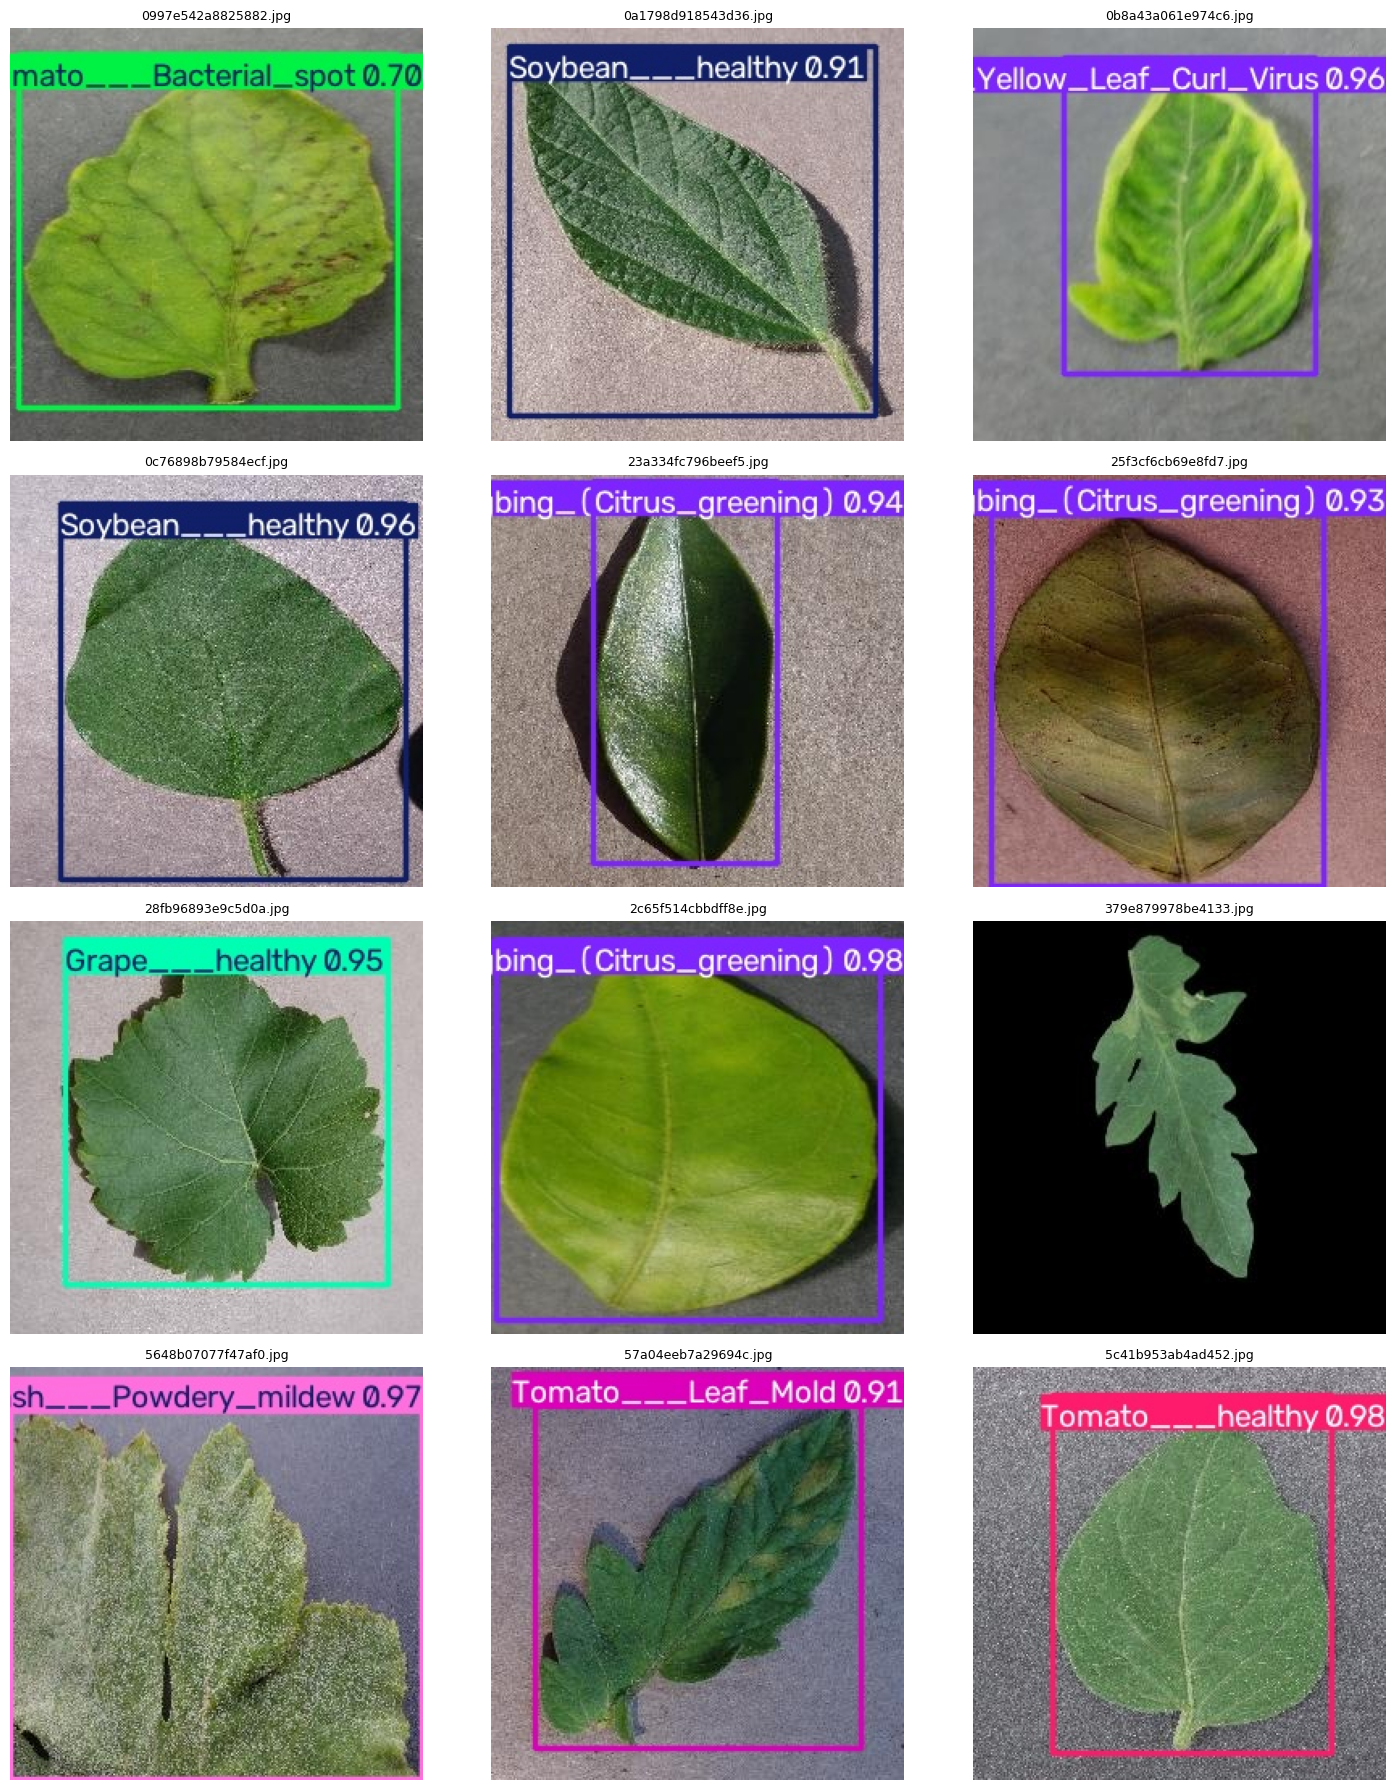

In [2]:
images_to_show = (
    prediction_images[:12]
)


fig, axes = plt.subplots(
    4,
    3,
    figsize=(15, 18)
)


axes = axes.flatten()


for ax in axes:
    ax.axis("off")


for i, image_path in enumerate(
    images_to_show
):

    image = Image.open(
        image_path
    ).convert("RGB")


    axes[i].imshow(
        image
    )

    axes[i].set_title(
        image_path.name,
        fontsize=9
    )

    axes[i].axis(
        "off"
    )


plt.tight_layout()
plt.show()

# STEP 24 — Display All Saved Test Predictions


In [ ]:
cols = 4

rows = (
    len(prediction_images)
    +
    cols
    -
    1
) // cols


fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(
        16,
        rows * 4
    )
)


axes = axes.flatten()


for ax in axes:
    ax.axis("off")


for i, image_path in enumerate(
    prediction_images
):

    image = Image.open(
        image_path
    ).convert("RGB")


    axes[i].imshow(
        image
    )

    axes[i].set_title(
        image_path.name,
        fontsize=8
    )

    axes[i].axis(
        "off"
    )


plt.tight_layout()
plt.show()

# STEP 25 — List Test Evaluation Figures


In [3]:
evaluation_images = sorted([
    p
    for p in TEST_EVAL_DIR.iterdir()
    if p.suffix.lower()
    in {
        ".jpg",
        ".jpeg",
        ".png"
    }
])


print(
    "Evaluation figures:",
    len(evaluation_images)
)


for p in evaluation_images:
    print(p.name)

Evaluation figures: 12
BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg


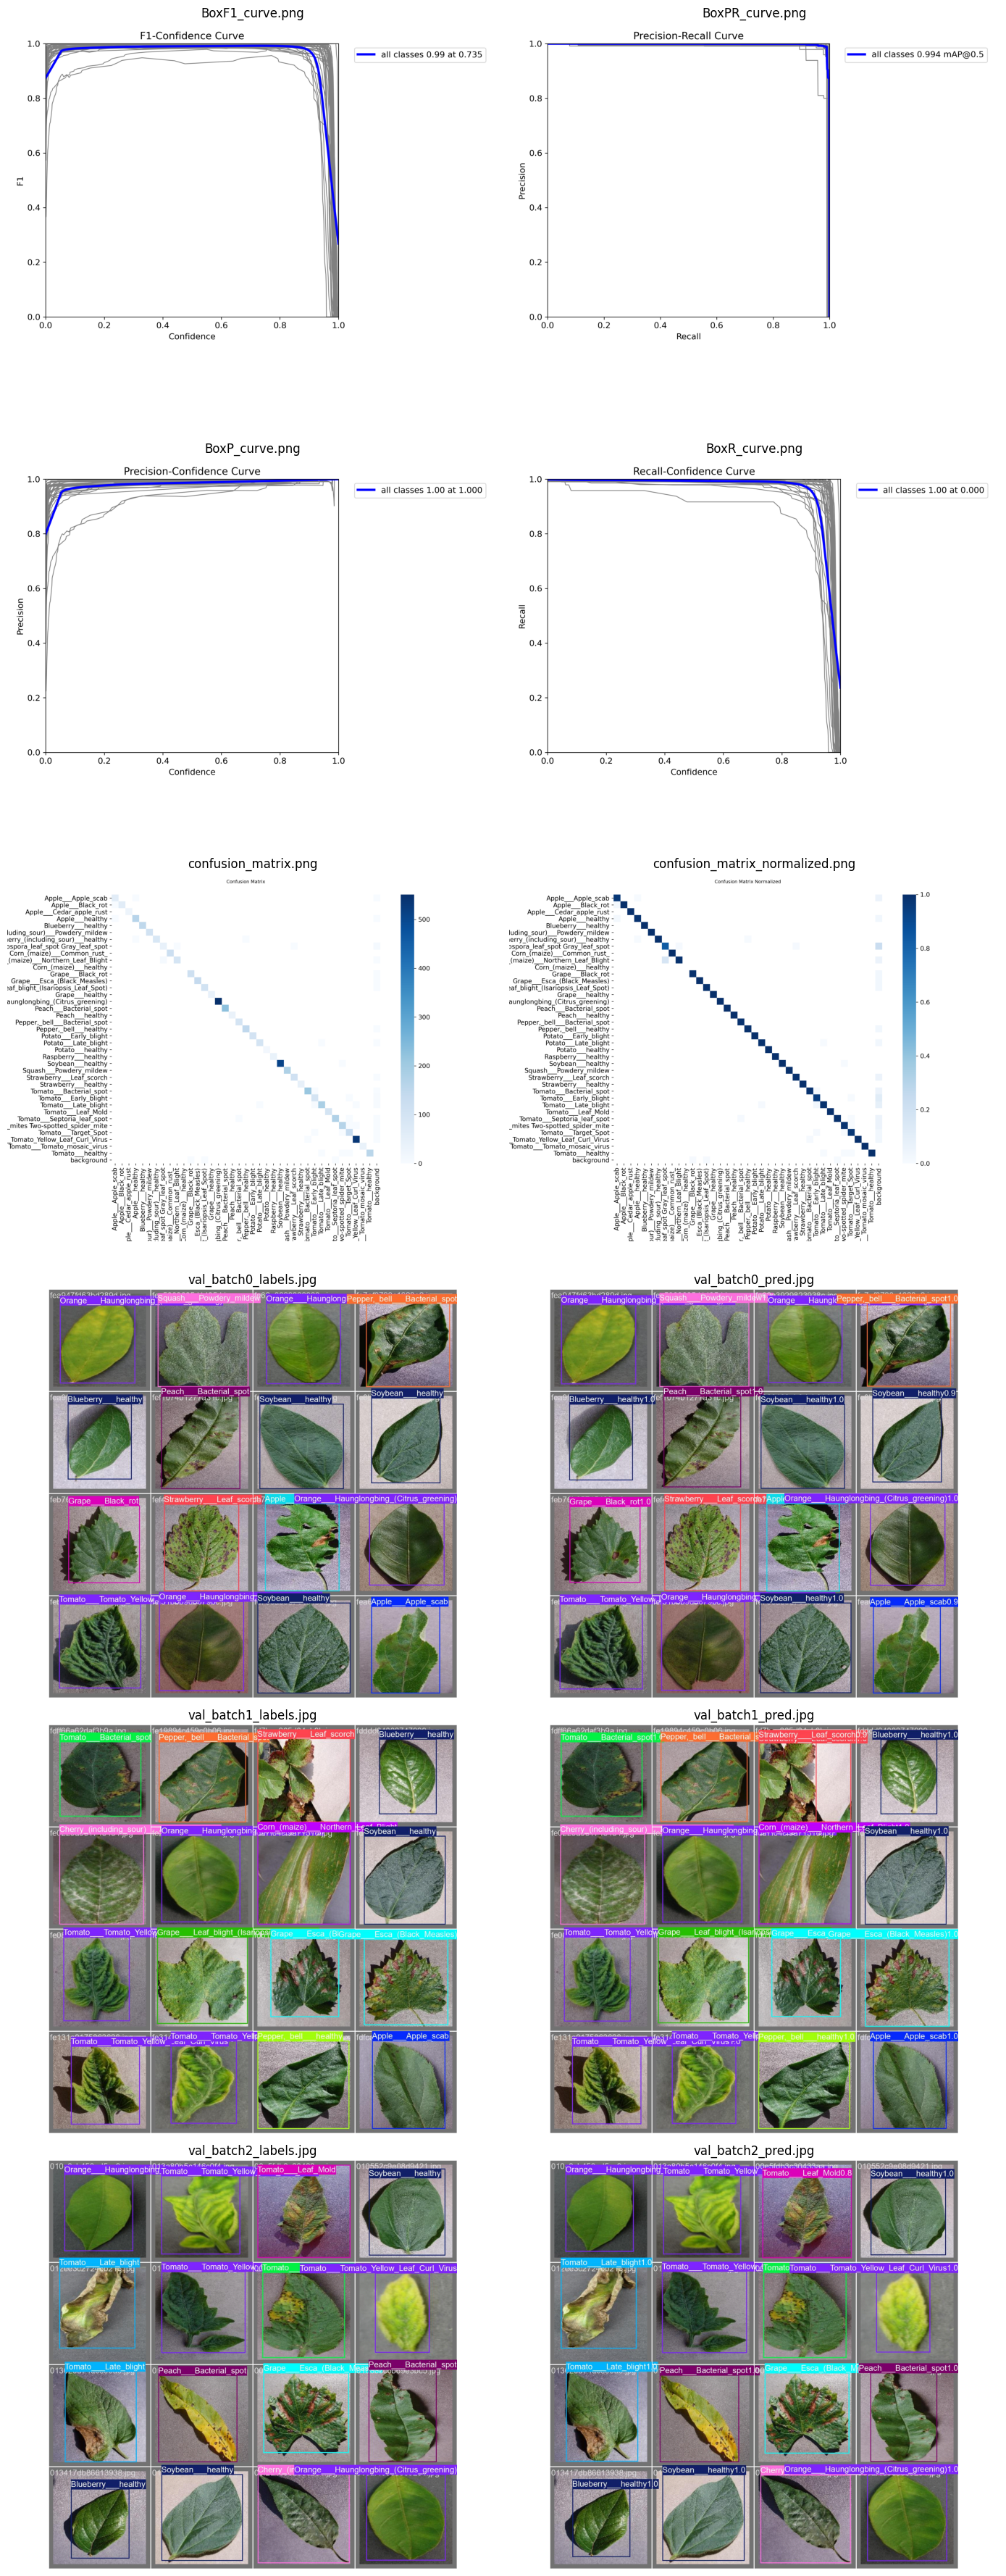

In [4]:
# ============================================================
# STEP 26 — Display Evaluation Figures
# ============================================================

if len(evaluation_images) > 0:

    cols = 2

    rows = (
        len(evaluation_images)
        +
        cols
        -
        1
    ) // cols


    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(
            14,
            rows * 6
        )
    )


    if len(evaluation_images) == 1:
        axes = [axes]

    else:
        axes = axes.flatten()


    for ax in axes:
        ax.axis("off")


    for i, path in enumerate(
        evaluation_images
    ):

        image = Image.open(
            path
        ).convert("RGB")


        axes[i].imshow(
            image
        )

        axes[i].set_title(
            path.name
        )

        axes[i].axis(
            "off"
        )


    plt.tight_layout()
    plt.show()

# If Power / Internet / Colab Disconnects

Do **not** manually edit epochs or checkpoint paths.

Simply:

1. Reopen this notebook.
2. Select a T4 GPU.
3. Make sure the same Drive folder is available.
4. Click **Run all**.

The notebook will:

```text
re-download public datasets
→ recreate temporary YOLO files
→ mount Drive
→ detect _STAGE_COMPLETE.json
→ skip completed stages
OR
→ detect last.pt
→ resume interrupted training
```

## To Continue from Another Gmail

Copy the whole folder:

```text
MyDrive/PlantVillage_Detection/
```

to the other Gmail's Drive with the **same folder name/path**.

For a partially trained model, make sure its experiment folder is copied too:

```text
PlantVillage_Detection/
└── experiments/
    └── MODEL_NAME/
        ├── 01_plantdoc_pretrain/
        └── 02_plantvillage_finetune/
```

Then open the same notebook in that account and use **Run all**.
